In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')


 # Clean captions
 # Create image → captions mapping
 # Build vocabulary
 # Numericalize captions
 # Extract image features (ResNet50/EfficientNet)
 # Create CaptionDataset
 # Create DataLoader with padding
 # Build Transformer Encoder–Decoder
 # Train
 # Evaluate with BLEU score

In [2]:
images_path ="/kaggle/input/datasets/abhinavbenagi/flickr30k/Images/Images"
captions_path ="/kaggle/input/datasets/abhinavbenagi/flickr30k/captions.txt"

In [3]:
import pandas as pd

df = pd.read_csv(captions_path)
print(df.head())

            image                                            caption
0  1000092795.jpg  Two young guys with shaggy hair look at their ...
1  1000092795.jpg  Two young  White males are outside near many b...
2  1000092795.jpg   Two men in green shirts are standing in a yard .
3  1000092795.jpg       A man in a blue shirt standing in a garden .
4  1000092795.jpg            Two friends enjoy time spent together .


In [4]:
# Caption Cleaning 
import re
import string

def clean_text(caption):
    caption = caption.lower()

    # Remove punctuation
    caption = caption.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove numbers
    caption = re.sub(r'\d+', '', caption)

    # Remove extra spaces
    caption = ' '.join(caption.split())

    # Remove single-character words
    caption = ' '.join(
        [word for word in caption.split() if len(word) > 1]
    )

    return caption

In [5]:
df['caption'] = df['caption'].apply(clean_text)

df['caption'].head()

0    two young guys with shaggy hair look at their ...
1    two young white males are outside near many bu...
2         two men in green shirts are standing in yard
3                 man in blue shirt standing in garden
4                two friends enjoy time spent together
Name: caption, dtype: object

In [6]:
from collections import defaultdict

image_caption_mapping = defaultdict(list)

for _, row in df.iterrows():

    image_name = row['image']

    caption = clean_text(row['caption'])

    # Skip empty captions
    if len(caption.split()) < 2:
        continue

    # Skip extremely long captions
    if len(caption.split()) > 30:
        continue

    # Add special tokens ONLY HERE
    caption = f"<start> {caption} <end>"

    image_caption_mapping[image_name].append(caption)

print("Total Images:", len(image_caption_mapping))

Total Images: 31783


In [7]:
first_img = list(image_caption_mapping.keys())[0]

print(first_img)
print(image_caption_mapping[first_img][:3])

1000092795.jpg
['<start> two young guys with shaggy hair look at their hands while hanging out in the yard <end>', '<start> two young white males are outside near many bushes <end>', '<start> two men in green shirts are standing in yard <end>']


In [8]:
import re
from collections import Counter

class Vocabulary:

    def __init__(self, freq_threshold=5):

        self.freq_threshold = freq_threshold

        self.word2idx = {
            "<PAD>": 0,
            "<UNK>": 1
        }

        self.idx2word = {
            0: "<PAD>",
            1: "<UNK>"
        }

    def tokenizer(self, text):

        text = text.lower()

        return text.split()

    def build_vocab(self, captions):

        counter = Counter()

        for caption in captions:
            counter.update(self.tokenizer(caption))

        idx = len(self.word2idx)

        for word, freq in counter.items():

            if freq >= self.freq_threshold:

                self.word2idx[word] = idx
                self.idx2word[idx] = word

                idx += 1

    def numericalize(self, text):

        tokens = self.tokenizer(text)

        return [
            self.word2idx.get(token, self.word2idx["<UNK>"])
            for token in tokens
        ]

    def __len__(self):

        return len(self.word2idx)

In [9]:
all_captions = []

for captions in image_caption_mapping.values():
    all_captions.extend(captions)

vocab = Vocabulary(freq_threshold=5)

vocab.build_vocab(all_captions)

print("Vocabulary Size:", len(vocab))

Vocabulary Size: 7621


In [10]:
sample = image_caption_mapping[first_img][0]

print(sample)

print(vocab.numericalize(sample))

<start> two young guys with shaggy hair look at their hands while hanging out in the yard <end>
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [11]:
print(df.shape)

(158915, 2)


In [12]:
import os
import numpy as np
from tqdm import tqdm

from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model

2026-06-24 04:59:40.973901: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782277181.158302      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782277181.209285      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782277181.643068      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782277181.643115      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782277181.643118      58 computation_placer.cc:177] computation placer alr

In [13]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last 20 layers
for layer in base_model.layers[-20:]:
    layer.trainable = True

feature_extractor = Model(
    inputs=base_model.input,
    outputs=base_model.output
)

print("Output Shape:", feature_extractor.output_shape)

I0000 00:00:1782277195.340931      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782277195.346937      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Output Shape: (None, 2048)


In [14]:
def extract_feature(img_path):

    img = load_img(
        img_path,
        target_size=(224, 224)
    )

    img = img_to_array(img)

    img = np.expand_dims(
        img,
        axis=0
    )

    img = preprocess_input(img)

    feature = feature_extractor.predict(
        img,
        verbose=0
    )

    return feature.flatten()

In [15]:
import os
from tqdm.auto import tqdm

features = {}

image_names = list(image_caption_mapping.keys())

for image_name in tqdm(
    image_names,
    total=len(image_names),
    desc="Extracting ResNet Features"
):

    image_path = os.path.join(
        images_path,
        image_name
    )

    if not os.path.exists(image_path):
        continue

    try:
        features[image_name] = extract_feature(
            image_path
        )

    except Exception as e:
        print(f"Error: {image_name}")
        continue

Extracting ResNet Features:   0%|          | 0/31783 [00:00<?, ?it/s]

I0000 00:00:1782277200.407892     125 service.cc:152] XLA service 0x7aa0d0003290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782277200.407942     125 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782277200.407949     125 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782277201.229782     125 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782277203.942157     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [16]:
import numpy as np

np.savez(
    "features.npz",
    **features
)

print(
    f"Saved {len(features)} image features."
)

Saved 31783 image features.


In [17]:
loaded = np.load(
    "features.npz",
    allow_pickle=True
)

features = {
    k: loaded[k]
    for k in loaded.files
}

loaded.close()

In [18]:
print(type(features))

<class 'dict'>


In [19]:
first_img = list(features.keys())[0]

print(first_img)
print(features[first_img].shape)

1000092795.jpg
(2048,)


In [20]:
from tqdm.auto import tqdm

samples = []

for img_name, captions in tqdm(
    image_caption_mapping.items(),
    desc="Creating Samples"
):

    if img_name not in features:
        continue

    for caption in captions:
        samples.append(
            (img_name, caption)
        )

print("Total Samples:", len(samples))

Creating Samples:   0%|          | 0/31783 [00:00<?, ?it/s]

Total Samples: 158299


In [21]:
import torch
from torch.utils.data import Dataset

class CaptionDataset(Dataset):

    def __init__(
        self,
        samples,
        features,
        vocab,
        max_len
    ):
        self.samples = samples
        self.features = features
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        img_name, caption = self.samples[idx]

        # Image Feature
        image_feature = torch.tensor(
            self.features[img_name],
            dtype=torch.float32
        )

        # Caption IDs
        caption_ids = self.vocab.numericalize(
            caption
        )

        # Padding
        if len(caption_ids) < self.max_len:

            caption_ids += (
                [self.vocab.word2idx["<PAD>"]]
                * (self.max_len - len(caption_ids))
            )

        else:
            caption_ids = caption_ids[:self.max_len]

        caption_ids = torch.tensor(
            caption_ids,
            dtype=torch.long
        )

        return image_feature, caption_ids

In [22]:
max_len = max(
    len(vocab.numericalize(cap))
    for cap in all_captions
)

print(max_len)

32


In [23]:
dataset = CaptionDataset(
    samples=samples,
    features=features,   # dict
    vocab=vocab,
    max_len=max_len
)

print("Dataset Size:", len(dataset))

Dataset Size: 158299


In [24]:
image_feature, caption = dataset[0]

print(image_feature.shape)
print(caption.shape)

torch.Size([2048])
torch.Size([32])


In [25]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0
)

image_features, captions = next(iter(train_loader))

print(image_features.shape)
print(captions.shape)

torch.Size([64, 2048])
torch.Size([64, 32])


In [26]:
print(type(features))

<class 'dict'>


In [27]:
for image_features, captions in train_loader:
    print(image_features.shape)
    print(captions.shape)
    break

torch.Size([64, 2048])
torch.Size([64, 32])


In [36]:
BATCH_SIZE = 64
LR = 1e-4
EPOCHS = 40

EMBED_DIM = 512
NUM_HEADS = 8
NUM_LAYERS = 4
DROPOUT = 0.1

In [37]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(
            0,
            max_len
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2
            ) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer(
            "pe",
            pe.unsqueeze(0)
        )

    def forward(self, x):

        return x + self.pe[:, :x.size(1)]

In [38]:
import torch
import torch.nn as nn

class CaptionTransformer(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model=512,
        nhead=8,
        num_layers=3,
        dropout=0.1,
        max_len=40
    ):
        super().__init__()

        # Image feature projection
        self.image_proj = nn.Linear(
            2048,
            d_model
        )

        # Word embedding
        self.embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.pos_encoding = PositionalEncoding(
            d_model,
            max_len
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )

        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(
            d_model,
            vocab_size
        )

    def forward(
        self,
        image_features,
        captions
    ):

        memory = self.image_proj(
            image_features
        )

        memory = memory.unsqueeze(1)

        caption_embed = self.embedding(
            captions
        )

        caption_embed = self.pos_encoding(
            caption_embed
        )

        seq_len = captions.size(1)

        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            seq_len
        ).to(captions.device)

        output = self.decoder(
            tgt=caption_embed,
            memory=memory,
            tgt_mask=tgt_mask
        )

        output = self.fc(output)

        return output

In [39]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = CaptionTransformer(
    vocab_size=len(vocab),
    d_model=512,
    nhead=8,
    num_layers=3
).to(device)

print(model)

CaptionTransformer(
  (image_proj): Linear(in_features=2048, out_features=512, bias=True)
  (embedding): Embedding(7621, 512)
  (pos_encoding): PositionalEncoding()
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm3): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout1):

In [40]:
image_features, captions = next(
    iter(train_loader)
)

image_features = image_features.to(device)
captions = captions.to(device)

output = model(
    image_features,
    captions[:, :-1]
)

print(output.shape)

torch.Size([64, 31, 7621])


In [41]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss(
    ignore_index=vocab.word2idx["<PAD>"]
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

In [42]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [43]:
from tqdm.auto import tqdm
import torch
best_loss = float("inf")

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    )

    for image_features, captions in train_bar:

        image_features = image_features.to(device)
        captions = captions.to(device)

        optimizer.zero_grad()

        outputs = model(
            image_features,
            captions[:, :-1]
        )

        targets = captions[:, 1:]

        loss = criterion(
            outputs.reshape(
                -1,
                outputs.shape[-1]
            ),
            targets.reshape(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    avg_loss = total_loss / len(train_loader)

    scheduler.step(avg_loss)

    print(
        f"\nEpoch {epoch+1}: Loss = {avg_loss:.4f}"
    )

    # Save Best Model
    if avg_loss < best_loss:

        best_loss = avg_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": avg_loss,
                "vocab_size": len(vocab),
                "max_len": max_len
            },
            "best_caption_model.pth"
        )

        print(
            f"✅ Best model saved "
            f"(Epoch {epoch+1}, Loss={avg_loss:.4f})"
        )

Epoch 1/40:   0%|          | 0/2474 [00:00<?, ?it/s]


Epoch 1: Loss = 4.1385
✅ Best model saved (Epoch 1, Loss=4.1385)


Epoch 2/40:   0%|          | 0/2474 [00:00<?, ?it/s]


Epoch 2: Loss = 3.4596
✅ Best model saved (Epoch 2, Loss=3.4596)


Epoch 3/40:   0%|          | 0/2474 [00:00<?, ?it/s]

...


Epoch 38: Loss = 1.4107
✅ Best model saved (Epoch 38, Loss=1.4107)


Epoch 39/40:   0%|          | 0/2474 [00:00<?, ?it/s]


Epoch 39: Loss = 1.3948
✅ Best model saved (Epoch 39, Loss=1.3948)


Epoch 40/40:   0%|          | 0/2474 [00:00<?, ?it/s]


Epoch 40: Loss = 1.3772
✅ Best model saved (Epoch 40, Loss=1.3772)


In [44]:
checkpoint = torch.load(
    "best_caption_model.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

print(
    f"Loaded model from Epoch {checkpoint['epoch']}"
)
print(
    f"Loss: {checkpoint['loss']:.4f}"
)

Loaded model from Epoch 40
Loss: 1.3772


In [45]:
torch.save(
    model.state_dict(),
    "final_caption_model.pth"
)

print("Final model saved.")

Final model saved.


In [46]:
import torch

def generate_caption(
    model,
    image_feature,
    vocab,
    max_len=40,
    device="cuda"
):

    model.eval()

    start_token = vocab.word2idx["<start>"]
    end_token = vocab.word2idx["<end>"]

    image_feature = torch.tensor(
        image_feature,
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    caption = [start_token]

    with torch.no_grad():

        for _ in range(max_len):

            caption_tensor = torch.tensor(
                caption,
                dtype=torch.long
            ).unsqueeze(0).to(device)

            output = model(
                image_feature,
                caption_tensor
            )

            next_word = output[:, -1, :].argmax(-1)

            next_word = next_word.item()

            caption.append(next_word)

            if next_word == end_token:
                break

    words = []

    for idx in caption:

        word = vocab.idx2word[idx]

        if word in ["<start>", "<end>", "<PAD>"]:
            continue

        words.append(word)

    return " ".join(words)

In [50]:
!pip install nltk

In [51]:
from nltk.translate.bleu_score import corpus_bleu
from tqdm.auto import tqdm

references = []
predictions = []

for img_name in tqdm(
    features.keys(),
    desc="BLEU Evaluation"
):

    pred = generate_caption(
        model,
        features[img_name],
        vocab,
        max_len=max_len,
        device=device
    )

    refs = []

    for cap in image_caption_mapping[img_name]:

        words = [
            w for w in cap.split()
            if w not in ["<start>", "<end>"]
        ]

        refs.append(words)

    predictions.append(pred.split())
    references.append(refs)

bleu1 = corpus_bleu(
    references,
    predictions,
    weights=(1,0,0,0)
)

bleu4 = corpus_bleu(
    references,
    predictions,
    weights=(0.25,0.25,0.25,0.25)
)

print(f"BLEU-1 : {bleu1:.4f}")
print(f"BLEU-4 : {bleu4:.4f}")

BLEU Evaluation:   0%|          | 0/31783 [00:00<?, ?it/s]

BLEU-1 : 0.7706
BLEU-4 : 0.4678


In [52]:
!pip install pycocoevalcap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 17.9 MB/s eta 0:00:0000:0100:01


In [54]:
gts = {}
res = {}

for idx, img_name in enumerate(features.keys()):

    refs = []

    for cap in image_caption_mapping[img_name]:

        cap = cap.replace("<start>", "")
        cap = cap.replace("<end>", "")
        refs.append(cap.strip())

    pred = generate_caption(
        model,
        features[img_name],
        vocab,
        max_len=max_len,
        device=device
    )

    gts[idx] = refs
    res[idx] = [pred]

In [55]:
from pycocoevalcap.cider.cider import Cider

cider_scorer = Cider()

score, scores = cider_scorer.compute_score(
    gts,
    res
)

print("CIDEr:", score)

CIDEr: 1.2837060576289168


In [56]:
beam_width = 3

In [57]:
def beam_search(
    model,
    image_feature,
    vocab,
    beam_width=3,
    max_len=40
):

    start = vocab.word2idx["<start>"]
    end = vocab.word2idx["<end>"]

    sequences = [([start], 0.0)]

    image_feature = torch.tensor(
        image_feature,
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        for _ in range(max_len):

            all_candidates = []

            for seq, score in sequences:

                if seq[-1] == end:

                    all_candidates.append(
                        (seq, score)
                    )

                    continue

                seq_tensor = torch.tensor(
                    seq
                ).unsqueeze(0).to(device)

                output = model(
                    image_feature,
                    seq_tensor
                )

                probs = torch.softmax(
                    output[:, -1],
                    dim=-1
                )

                topk_probs, topk_ids = torch.topk(
                    probs,
                    beam_width
                )

                for k in range(beam_width):

                    candidate = (
                        seq + [topk_ids[0][k].item()],
                        score - torch.log(
                            topk_probs[0][k]
                        ).item()
                    )

                    all_candidates.append(
                        candidate
                    )

            sequences = sorted(
                all_candidates,
                key=lambda x: x[1]
            )[:beam_width]

    best_seq = sequences[0][0]

    words = []

    for idx in best_seq:

        word = vocab.idx2word[idx]

        if word not in [
            "<start>",
            "<end>",
            "<PAD>"
        ]:
            words.append(word)

    return " ".join(words)

In [58]:
caption = beam_search(
    model,
    features[first_img],
    vocab,
    beam_width=5
)

print(caption)

man in blue shirt is taking picture of plant


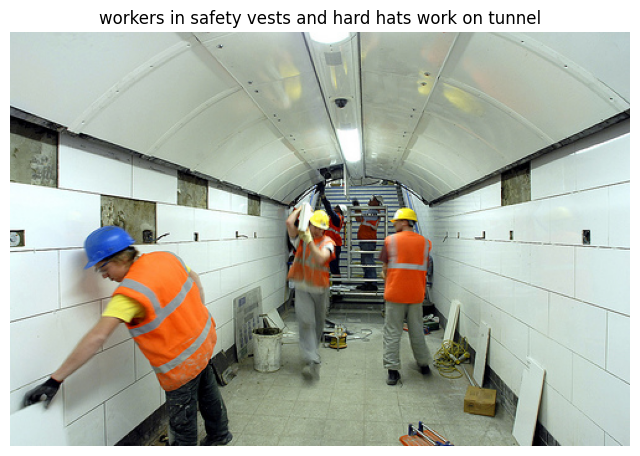

Image: 2541483099.jpg

Predicted Caption:
workers in safety vests and hard hats work on tunnel

Ground Truth Captions:
1. men working wearing orange safety vests and hard hats in hallway
2. construction workers are working on the side panels of tunnel
3. construction workers laying wall tile in hallway
4. construction workers are working in tunnel
5. workers place tiles on walls


In [77]:
import random
import os
import matplotlib.pyplot as plt
from PIL import Image

# Images folder
IMAGE_DIR = "/kaggle/input/datasets/abhinavbenagi/flickr30k/Images/Images"

# Random image
img_name = random.choice(list(features.keys()))

# Full image path
img_path = os.path.join(IMAGE_DIR, img_name)

# Check image exists
if not os.path.exists(img_path):
    print("Image not found:", img_path)

else:

    # Generate caption
    pred_caption = generate_caption(
        model,
        features[img_name],
        vocab,
        max_len=max_len,
        device=device
    )

    # Display image
    img = Image.open(img_path)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(pred_caption)
    plt.show()

    # Print captions
    print("=" * 100)
    print("Image:", img_name)

    print("\nPredicted Caption:")
    print(pred_caption)

    print("\nGround Truth Captions:")

    for i, cap in enumerate(image_caption_mapping[img_name], start=1):

        cap = cap.replace("<start>", "")
        cap = cap.replace("<end>", "")
        cap = cap.strip()

        print(f"{i}. {cap}")

    print("=" * 100)

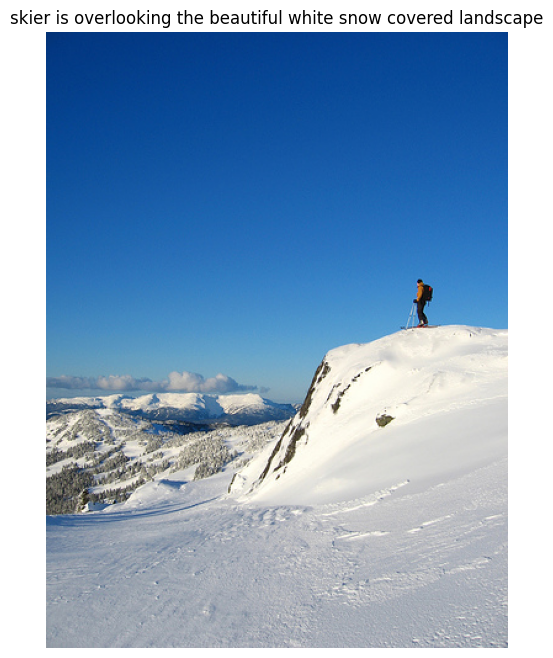

Image: 106514190.jpg

Predicted Caption:
skier is overlooking the beautiful white snow covered landscape

Ground Truth Captions:
1. skier is overlooking the beautiful white snow covered landscape
2. hiker standing high on bluff overlooking the mountains below
3. person on ski looks from hill over snow covered landscape
4. skier is overlooking snowcovered mountain
5. skier pauses on mountaintop


In [84]:
import random
import os
import matplotlib.pyplot as plt
from PIL import Image

# Images folder
IMAGE_DIR = "/kaggle/input/datasets/abhinavbenagi/flickr30k/Images/Images"

# Random image
img_name = random.choice(list(features.keys()))

# Full image path
img_path = os.path.join(IMAGE_DIR, img_name)

# Check image exists
if not os.path.exists(img_path):
    print("Image not found:", img_path)

else:

    # Generate caption
    pred_caption = generate_caption(
        model,
        features[img_name],
        vocab,
        max_len=max_len,
        device=device
    )

    # Display image
    img = Image.open(img_path)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(pred_caption)
    plt.show()

    # Print captions
    print("=" * 100)
    print("Image:", img_name)

    print("\nPredicted Caption:")
    print(pred_caption)

    print("\nGround Truth Captions:")

    for i, cap in enumerate(image_caption_mapping[img_name], start=1):

        cap = cap.replace("<start>", "")
        cap = cap.replace("<end>", "")
        cap = cap.strip()

        print(f"{i}. {cap}")

    print("=" * 100)